## AACR 会议 presentation 信息下载

URL: https://www.abstractsonline.com/pp8/#!/21436

**每年数据链接只有 URL 中最末尾数值会发生变化**

1. 会议内容组织方式为 session > presentation
2. 首先根据日程、或关注session 获取全部 presentation id，然后逐个id抓取对应内容
3. 其中 session 或会议日常没有规律，需要手动在网页端开发者模式中获取全部 json url 路径

In [1]:
import os 

os.listdir(".")

['AACR-2026.ipynb', '.ipynb_checkpoints']

## get all presentation id

- AACR 网站需要根据 backpack 信息验证真实用户
- backpack 信息获取来源为开发者模式 -> 网络 -> Headers
  > backpack 有效期约1天, 长时间运行需要关注是否过期

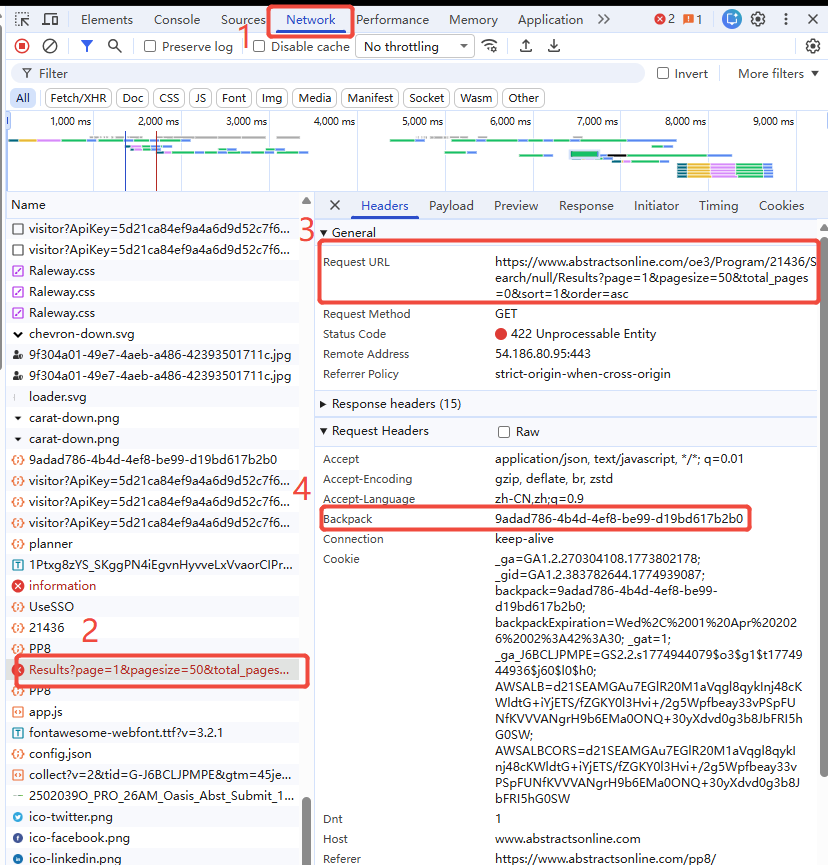

In [81]:
import json
import requests
from os.path import exists

def get_aacr_by_url(url, cahcefile=None):

    header = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36",
        # "cookie": "_ga=GA1.2.1393456963.1736303654; _ga_DR4SQFLWZ1=GS1.1.1739248782.3.0.1739248826.16.0.0; backpack=d886cb72-cb6b-4e95-8012-309f30af6108; backpackExpiration=Tue%2C%2013%20May%202025%2022%3A42%3A13; _gid=GA1.2.345013580.1747104134; _gat=1; _ga_J6BCLJPMPE=GS2.2.s1747104134$o39$g1$t1747104158$j36$l0$h0; AWSALB=hEXVwQlSTgv67pYxfkYWsg2vweytb479r2PgwLu1GHEYlm9a2M7SlMGTTX3zMNRbhXTe2YT0m04F9jDY2ap48b7JEcQqDmvREGz5taozx9YGdPLWN+mFoMr1lmYI; AWSALBCORS=hEXVwQlSTgv67pYxfkYWsg2vweytb479r2PgwLu1GHEYlm9a2M7SlMGTTX3zMNRbhXTe2YT0m04F9jDY2ap48b7JEcQqDmvREGz5taozx9YGdPLWN+mFoMr1lmYI",
        "backpack": "0dcaf40f-db4a-4a6f-87b3-8cdeea544a84",
        "content-type": "application/json",
        "accept": "application/json",
    }

    if (cahcefile is not None) and exists(cahcefile) and os.path.getsize(cahcefile) > 0: 
        with open(cahcefile) as fi: 
            content = json.load(fi)
            return content 
    
    res = requests.get(url, headers=header)
    content = res.json()
    if (cahcefile is not None): 
        with open(cahcefile, "w") as fi: 
            json.dump(content, fi, indent=2)

    return content

> 展示url通过 AACR2026 会议日常获取，不同日程对应 url 没有规律，需要浏览器手动获取

In [3]:
URL = "https://www.abstractsonline.com/oe3/Program/21436/Search/173/Results?page=1&pagesize=50&sort=1&order=asc"

apr17 = get_aacr_by_url(URL)

In [5]:
apr17.keys()

dict_keys(['Page', 'PageSize', 'Results', 'Search'])

In [11]:
apr17["Page"], apr17["PageSize"]

('1', '50')

In [6]:
apr17["Search"]

{'Count': '153',
 'DataSet': 'presentation',
 'Filters': None,
 'Phrase': '@timeSlot=Apr17',
 'SearchId': '173',
 'Status': 'Complete'}

In [10]:
apr17["Results"][0]

{'Actions': [{'Icon': '',
   'Label': 'Presentations view',
   'SubType': None,
   'Type': 'Presentation',
   'Url': None}],
 'Body': 'Chairperson',
 'CalendarDisplayBlock': None,
 'CardTemplate': '',
 'Details': None,
 'Foot': '',
 'GroupHeader': '',
 'Head': 'Apr 17 2026  1:00PM',
 'Id': '1720',
 'Key': None,
 'ListOrder': '1',
 'Thumbnail': '',
 'Type': 'Presentation'}

### for loop

In [39]:
from math import ceil
from os import makedirs

if not exists("schedule"):
    makedirs("schedule")


URLS = {
    "apr17": "https://www.abstractsonline.com/oe3/Program/21436/Search/173/Results?page={page}{suffix}&pagesize=50&sort=1&order=asc",
    "apr18": "https://www.abstractsonline.com/oe3/Program/21436/Search/30/Results?page={page}{suffix}&pagesize=50&sort=1&order=asc",
    "apr19": "https://www.abstractsonline.com/oe3/Program/21436/Search/82/Results?page={page}{suffix}&pagesize=50&sort=1&order=asc",
    "apr20": "https://www.abstractsonline.com/oe3/Program/21436/Search/127/Results?page={page}{suffix}&pagesize=50&sort=1&order=asc",
    "apr21": "https://www.abstractsonline.com/oe3/Program/21436/Search/36/Results?page={page}{suffix}&pagesize=50&sort=1&order=asc",
    "apr22": "https://www.abstractsonline.com/oe3/Program/21436/Search/124/Results?page={page}{suffix}&pagesize=50&sort=1&order=asc",
}

for x, y in URLS.items(): 
    page = 1
    url = y.format(page=page, suffix="")
    res = get_aacr_by_url(url, f"schedule/ids_{x}_{page}.json")
    total = int(res["Search"]["Count"])
    count = len(res["Results"])
    print(x, page, count, total, url)

    # "https://www.abstractsonline.com/oe3/Program/21436/Search/30/Results?page=3&pagesize=10&total_pages=47&total_entries=468&sort=1&order=asc"
    pages = ceil(total / 50)
    suffix = f"&total_pages={pages}&total_entries={total}"
    while count < total:
        page += 1
        url = y.format(page=page, suffix=suffix)
        res = get_aacr_by_url(url, f"ids_{x}_{page}.json")
        count += len(res["Results"])
        print(x, page, count, total, url)


apr17 1 50 153 https://www.abstractsonline.com/oe3/Program/21436/Search/173/Results?page=1&pagesize=50&sort=1&order=asc
apr17 2 100 153 https://www.abstractsonline.com/oe3/Program/21436/Search/173/Results?page=2&total_pages=4&total_entries=153&pagesize=50&sort=1&order=asc
apr17 3 150 153 https://www.abstractsonline.com/oe3/Program/21436/Search/173/Results?page=3&total_pages=4&total_entries=153&pagesize=50&sort=1&order=asc
apr17 4 153 153 https://www.abstractsonline.com/oe3/Program/21436/Search/173/Results?page=4&total_pages=4&total_entries=153&pagesize=50&sort=1&order=asc
apr18 1 50 468 https://www.abstractsonline.com/oe3/Program/21436/Search/30/Results?page=1&pagesize=50&sort=1&order=asc
apr18 2 100 468 https://www.abstractsonline.com/oe3/Program/21436/Search/30/Results?page=2&total_pages=10&total_entries=468&pagesize=50&sort=1&order=asc
apr18 3 150 468 https://www.abstractsonline.com/oe3/Program/21436/Search/30/Results?page=3&total_pages=10&total_entries=468&pagesize=50&sort=1&order=

## merge multiple id files

In [41]:
import glob
import pandas as pd 

xls = glob.glob("schedule/*ids*json")

presentation = []
for file in xls:
    with open(file) as fi: 
        data = json.load(fi)
    presentation.extend(data["Results"])

len(presentation)

9645

In [42]:
len([item for item in presentation if len(item["Actions"]) > 1])

0

In [43]:
for item in presentation:
    if isinstance(item["Actions"], list): 
        item.update({
            f"Actions.{x}": y for x, y in item["Actions"][0].items()
        })

dat = pd.DataFrame(presentation)

dat.head()

,Actions,Body,CalendarDisplayBlock,CardTemplate,Details,Foot,GroupHeader,Head,Id,Key,ListOrder,Thumbnail,Type,Actions.Icon,Actions.Label,Actions.SubType,Actions.Type,Actions.Url
0,"[{'Icon': '', 'Label': 'Presentations view', '...",5146. Discovery of a novel ALK inhibitor ZM-81...,None,,None,,,Apr 21 2026 9:00AM,6428,None,1,https://us-cslide-prod-presentations.s3.us-wes...,Presentation,,Presentations view,None,Presentation,None
1,"[{'Icon': '', 'Label': 'Presentations view', '...",5147. A novel investigation of the cyclin A/B ...,None,,None,,,Apr 21 2026 9:00AM,6415,None,2,https://us-cslide-prod-presentations.s3.us-wes...,Presentation,,Presentations view,None,Presentation,None
2,"[{'Icon': '', 'Label': 'Presentations view', '...",5151. Design and synthesis of highly efficacio...,None,,None,,,Apr 21 2026 9:00AM,6442,None,3,,Presentation,,Presentations view,None,Presentation,None
3,"[{'Icon': '', 'Label': 'Presentations view', '...",5152. Targeted degradation of KRAS using the A...,None,,None,,,Apr 21 2026 9:00AM,6443,None,4,,Presentation,,Presentations view,None,Presentation,None
4,"[{'Icon': '', 'Label': 'Presentations view', '...",5153. Characterization of second-generation AU...,None,,None,,,Apr 21 2026 9:00AM,6444,None,5,,Presentation,,Presentations view,None,Presentation,None


In [44]:
dat = dat.drop("Actions", axis=1) 
dat.head()

,Body,CalendarDisplayBlock,CardTemplate,Details,Foot,GroupHeader,Head,Id,Key,ListOrder,Thumbnail,Type,Actions.Icon,Actions.Label,Actions.SubType,Actions.Type,Actions.Url
0,5146. Discovery of a novel ALK inhibitor ZM-81...,None,,None,,,Apr 21 2026 9:00AM,6428,None,1,https://us-cslide-prod-presentations.s3.us-wes...,Presentation,,Presentations view,None,Presentation,None
1,5147. A novel investigation of the cyclin A/B ...,None,,None,,,Apr 21 2026 9:00AM,6415,None,2,https://us-cslide-prod-presentations.s3.us-wes...,Presentation,,Presentations view,None,Presentation,None
2,5151. Design and synthesis of highly efficacio...,None,,None,,,Apr 21 2026 9:00AM,6442,None,3,,Presentation,,Presentations view,None,Presentation,None
3,5152. Targeted degradation of KRAS using the A...,None,,None,,,Apr 21 2026 9:00AM,6443,None,4,,Presentation,,Presentations view,None,Presentation,None
4,5153. Characterization of second-generation AU...,None,,None,,,Apr 21 2026 9:00AM,6444,None,5,,Presentation,,Presentations view,None,Presentation,None


In [45]:
dat["Id"].nunique()

9645

In [46]:
dat.shape 

(9645, 17)

## get presentation details

> 根据会议日常获取的全部 presentation id list，逐项获取 presetation 内容
> 
> presentation URL 同样通过网页端浏览器开发者模式获取
>
> **需要注意的事，这里URL不是网址，需要开发者模式查看网络数据中的数据交换URL**

In [50]:
from tqdm import tqdm

if not exists("presentation"):
    makedirs("presentation")

data = {}
for sid in tqdm(dat["Id"]):
    url = f"https://www.abstractsonline.com/oe3/Program/21436/Presentation/{sid}"
    content = get_aacr_by_url(url, f"presentation/{sid}_summary.json")
    data[sid] = content

100%|██████████| 9645/9645 [3:28:06<00:00,  1.29s/it]  


In [53]:
len(data)

9645

In [58]:
for _, item in data.items():
    if item.get("Actions"):
        item.update({
                f"Actions.{x}": y for x, y in item["Actions"][0].items()
        })
    if item.get("AdditionalFields"):
        item.update({
                f"AdditionalFields.{x['Key']}": x["Value"] for x in item["AdditionalFields"]
        })

dat = pd.DataFrame(data).T 
dat.head() 

,Abstract,Actions,Activity,AdditionalFields,AdditionalFiles,AllowAttendeeRating,AttendeeRatingAvg,AttendeeRatingCount,AuthorBlock,CSlideId,...,AdditionalFields.VideoType,AdditionalFields.cSlidePresentationId,AdditionalFields.EposterLinkfromPlannertoCattendee,AdditionalFields.ePosterLink,AdditionalFields.WebcastProgramPlannerLink,AdditionalInformation,ErrorCode,ErrorNumber,Message,Reference
6428,ALK fusions are common oncogenic drivers. Appr...,"[{'Icon': None, 'Label': 'View Abstract', 'Sub...",Abstract Submission,"[{'Key': 'Topics', 'Value': '++CH01-04 Drug de...",None,None,None,None,"Zhen Li<sup></sup>, Yajing Liu<sup></sup>, Men...",,...,,,,,,NaN,NaN,NaN,NaN,NaN
6415,Cyclins A and B are critical regulators of the...,"[{'Icon': None, 'Label': 'View Abstract', 'Sub...",Abstract Submission,"[{'Key': 'Topics', 'Value': '++CH01-04 Drug de...",None,None,None,None,"Guimei Yang<sup></sup>, Ruina Wang<sup></sup>,...",,...,,,,,,NaN,NaN,NaN,NaN,NaN
6442,Oncogenic mutation of KRAS is one of the most ...,"[{'Icon': None, 'Label': 'View Abstract', 'Sub...",Abstract Submission,"[{'Key': 'Topics', 'Value': '++CH01-04 Drug de...",None,None,None,None,"<b>Changwei Wang</b><sup>1</sup>, Prithwish Gh...",,...,,,,,,NaN,NaN,NaN,NaN,NaN
6443,RAS is one of the most frequently mutated onco...,"[{'Icon': None, 'Label': 'View Abstract', 'Sub...",Abstract Submission,"[{'Key': 'Topics', 'Value': '++CH01-09 Targete...",None,None,None,None,"<b>Su Ran Mun</b><sup>1</sup>, Su Jin Lee<sup>...",,...,,,,,,NaN,NaN,NaN,NaN,NaN
6444,Background: The androgen receptor (AR) drives ...,"[{'Icon': None, 'Label': 'View Abstract', 'Sub...",Abstract Submission,"[{'Key': 'Topics', 'Value': '++CH01-09 Targete...",None,None,None,None,"<b>Tri Pham</b><sup>1</sup>, Su Jin Lee<sup>2<...",,...,,,,,,NaN,NaN,NaN,NaN,NaN


In [60]:
dat = dat.drop(["Actions", "AdditionalFields"], axis=1) 
dat.head()

,Abstract,Activity,AdditionalFiles,AllowAttendeeRating,AttendeeRatingAvg,AttendeeRatingCount,AuthorBlock,CSlideId,ControlKey,ControlNumber,...,AdditionalFields.VideoType,AdditionalFields.cSlidePresentationId,AdditionalFields.EposterLinkfromPlannertoCattendee,AdditionalFields.ePosterLink,AdditionalFields.WebcastProgramPlannerLink,AdditionalInformation,ErrorCode,ErrorNumber,Message,Reference
6428,ALK fusions are common oncogenic drivers. Appr...,Abstract Submission,None,None,None,None,"Zhen Li<sup></sup>, Yajing Liu<sup></sup>, Men...",,93f65e0f-8241-48e5-bd29-8db80aeba0ef,5313,...,,,,,,NaN,NaN,NaN,NaN,NaN
6415,Cyclins A and B are critical regulators of the...,Abstract Submission,None,None,None,None,"Guimei Yang<sup></sup>, Ruina Wang<sup></sup>,...",,74b81ed3-b083-4692-bd1b-0fad922dc9ae,3673,...,,,,,,NaN,NaN,NaN,NaN,NaN
6442,Oncogenic mutation of KRAS is one of the most ...,Abstract Submission,None,None,None,None,"<b>Changwei Wang</b><sup>1</sup>, Prithwish Gh...",,56c81e93-ee3b-413d-bc22-70a4eb4c83d9,4386,...,,,,,,NaN,NaN,NaN,NaN,NaN
6443,RAS is one of the most frequently mutated onco...,Abstract Submission,None,None,None,None,"<b>Su Ran Mun</b><sup>1</sup>, Su Jin Lee<sup>...",,dfa297b1-0d66-4e65-853e-26889b4b3c46,1880,...,,,,,,NaN,NaN,NaN,NaN,NaN
6444,Background: The androgen receptor (AR) drives ...,Abstract Submission,None,None,None,None,"<b>Tri Pham</b><sup>1</sup>, Su Jin Lee<sup>2<...",,f62f91aa-9fc7-4f80-9d4a-42cb1f8911fb,4488,...,,,,,,NaN,NaN,NaN,NaN,NaN


## output excel file

In [62]:
dat["presentation_url"] = dat["Id"].apply(lambda x: f"https://www.abstractsonline.com/pp8/#!/21436/presentation/{x}")
dat["session_url"] = dat["SessionId"].apply(lambda x: f"https://www.abstractsonline.com/pp8/#!/21436/session/{x}")

dat.head()

,Abstract,Activity,AdditionalFiles,AllowAttendeeRating,AttendeeRatingAvg,AttendeeRatingCount,AuthorBlock,CSlideId,ControlKey,ControlNumber,...,AdditionalFields.EposterLinkfromPlannertoCattendee,AdditionalFields.ePosterLink,AdditionalFields.WebcastProgramPlannerLink,AdditionalInformation,ErrorCode,ErrorNumber,Message,Reference,presentation_url,session_url
6428,ALK fusions are common oncogenic drivers. Appr...,Abstract Submission,None,None,None,None,"Zhen Li<sup></sup>, Yajing Liu<sup></sup>, Men...",,93f65e0f-8241-48e5-bd29-8db80aeba0ef,5313,...,,,,NaN,NaN,NaN,NaN,NaN,https://www.abstractsonline.com/pp8/#!/21436/p...,https://www.abstractsonline.com/pp8/#!/21436/s...
6415,Cyclins A and B are critical regulators of the...,Abstract Submission,None,None,None,None,"Guimei Yang<sup></sup>, Ruina Wang<sup></sup>,...",,74b81ed3-b083-4692-bd1b-0fad922dc9ae,3673,...,,,,NaN,NaN,NaN,NaN,NaN,https://www.abstractsonline.com/pp8/#!/21436/p...,https://www.abstractsonline.com/pp8/#!/21436/s...
6442,Oncogenic mutation of KRAS is one of the most ...,Abstract Submission,None,None,None,None,"<b>Changwei Wang</b><sup>1</sup>, Prithwish Gh...",,56c81e93-ee3b-413d-bc22-70a4eb4c83d9,4386,...,,,,NaN,NaN,NaN,NaN,NaN,https://www.abstractsonline.com/pp8/#!/21436/p...,https://www.abstractsonline.com/pp8/#!/21436/s...
6443,RAS is one of the most frequently mutated onco...,Abstract Submission,None,None,None,None,"<b>Su Ran Mun</b><sup>1</sup>, Su Jin Lee<sup>...",,dfa297b1-0d66-4e65-853e-26889b4b3c46,1880,...,,,,NaN,NaN,NaN,NaN,NaN,https://www.abstractsonline.com/pp8/#!/21436/p...,https://www.abstractsonline.com/pp8/#!/21436/s...
6444,Background: The androgen receptor (AR) drives ...,Abstract Submission,None,None,None,None,"<b>Tri Pham</b><sup>1</sup>, Su Jin Lee<sup>2<...",,f62f91aa-9fc7-4f80-9d4a-42cb1f8911fb,4488,...,,,,NaN,NaN,NaN,NaN,NaN,https://www.abstractsonline.com/pp8/#!/21436/p...,https://www.abstractsonline.com/pp8/#!/21436/s...


In [65]:
dat['PlayerUrl'].unique()

array(['https://files.abstractsonline.com/SUPT/101/20273/cfg-cattendee-cslide-player-view-content-not-registered.png',
       'https://files.abstractsonline.com/SUPT/101/20273/cfg-cattendee-cslide-player-view-content-embargoed.png',
       nan], dtype=object)

In [67]:
dat = dat.drop(["PlayerUrl", "PlayerUrlReason"], axis=1) 

In [69]:
cols = ["SessionId", "SessionTitle", "Id", "Title", "Abstract"]

dat = dat.sort_values(cols)

### remove html element

In [72]:
from bs4 import BeautifulSoup

def clean_html(text):
    return BeautifulSoup(text, "html.parser").get_text()

dat = dat.fillna("")
dat["DisclosureBlock"] = dat["DisclosureBlock"].apply(clean_html)
dat["AuthorBlock"] = dat["AuthorBlock"].apply(clean_html)
dat["Abstract"] = dat["Abstract"].apply(clean_html)

/tmp/ipykernel_1412928/2317751698.py:4: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()


In [75]:
dat["Title"] = dat["Title"].apply(clean_html)

/tmp/ipykernel_1412928/2317751698.py:4: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()


In [76]:
dat.to_excel("AACR_2026.xlsx", sheet_name="Sheet1", index=False)

## get location & type from session 

In [77]:
len(dat["SessionId"].unique())

636

In [87]:
from tqdm import tqdm

if not exists("session"):
    makedirs("session")

data = {}
for sid in tqdm(dat["SessionId"].unique()):
    if not sid:
        continue
    url = f"https://www.abstractsonline.com/oe3/Program/21436/Session/{sid}"
    content = get_aacr_by_url(url, f"session/{sid}_summary.json")
    data[sid] = content

100%|██████████| 636/636 [00:00<00:00, 19324.95it/s]


In [88]:
content

{'AdditionalFields': [{'Key': 'AACROrganSiteAll', 'Value': ''},
  {'Key': 'AACRTrackAll',
   'Value': 'Bioinformatics / Computational Biology / Artificial Intelligence / Data Science,Tumor Biology,Prevention / Early Detection / Interception'},
  {'Key': 'CEHoursPP8', 'Value': ''},
  {'Key': 'LivecastUrl', 'Value': ''},
  {'Key': 'RelatedArticlesProgPlan', 'Value': ''},
  {'Key': 'SessionCategoryBasic', 'Value': ''},
  {'Key': 'SessionName', 'Value': 'Advances in Technologies'},
  {'Key': 'VideoType', 'Value': ''},
  {'Key': 'WebcastIPSessionLink', 'Value': ''},
  {'Key': 'Presentation Count', 'Value': '9'}],
 'BoothSponsorshipIdForCalendar': None,
 'BoothSponsorshipIdForDetail': None,
 'BoothSponsorshipIdForResult': None,
 'CSlideId': None,
 'Color': '',
 'ContentCaptureVendorSpecification': None,
 'Created': None,
 'Date': '2026-04-19',
 'Description': '<p>Foundation models (FMs) are general-purpose encoders pretrained on large collections of domain-specific but unlabeled data using s

In [89]:
for _, item in data.items():
    if item.get("AdditionalFields"):
        item.update({
                f"AdditionalFields.{x['Key']}": x["Value"] for x in item["AdditionalFields"]
        })

df = pd.DataFrame(data).T 
df.head() 

,AdditionalFields,BoothSponsorshipIdForCalendar,BoothSponsorshipIdForDetail,BoothSponsorshipIdForResult,CSlideId,Color,ContentCaptureVendorSpecification,Created,Date,Description,...,AdditionalFields.AACROrganSiteAll,AdditionalFields.AACRTrackAll,AdditionalFields.CEHoursPP8,AdditionalFields.LivecastUrl,AdditionalFields.RelatedArticlesProgPlan,AdditionalFields.SessionCategoryBasic,AdditionalFields.SessionName,AdditionalFields.VideoType,AdditionalFields.WebcastIPSessionLink,AdditionalFields.Presentation Count
1,"[{'Key': 'AACROrganSiteAll', 'Value': ''}, {'K...",None,None,None,None,,None,None,2026-04-19,<p>The AACR Annual Meeting brings together sen...,...,,"Career Development,Multidisciplinary",,,,,Special Session,,,6
100,"[{'Key': 'AACROrganSiteAll', 'Value': ''}, {'K...",None,None,None,None,CadetBlue,None,None,2026-04-22,As precision medicine continues to transform c...,...,,Bioinformatics / Computational Biology / Artif...,,,,,Advances in the Science of Cancer Disparities,,,9
101,"[{'Key': 'AACROrganSiteAll', 'Value': ''}, {'K...",None,None,None,None,CadetBlue,None,None,2026-04-20,Living in persistent poverty areas is a signif...,...,,"Population Sciences,Cancer Disparities,Global ...",,,,,Advances in the Science of Cancer Disparities,,,9
102,"[{'Key': 'AACROrganSiteAll', 'Value': ''}, {'K...",None,None,None,None,,None,None,2026-04-20,"Cancer cell plasticity, defined as the ability...",...,,"Tumor Biology,Cancer Evolution",,,,,Major Symposium,,,9
103,"[{'Key': 'AACROrganSiteAll', 'Value': ''}, {'K...",None,None,None,None,,None,None,2026-04-20,The tumor microenvironment (TME) is a dynamic ...,...,,"Tumor Biology,Tumor Microenvironment",,,,,Major Symposium,,,7


In [90]:
df = df.drop("AdditionalFields", axis=1)
df["Description"] = df["Description"].fillna(clean_html)
df.head()

,BoothSponsorshipIdForCalendar,BoothSponsorshipIdForDetail,BoothSponsorshipIdForResult,CSlideId,Color,ContentCaptureVendorSpecification,Created,Date,Description,Duration,...,AdditionalFields.AACROrganSiteAll,AdditionalFields.AACRTrackAll,AdditionalFields.CEHoursPP8,AdditionalFields.LivecastUrl,AdditionalFields.RelatedArticlesProgPlan,AdditionalFields.SessionCategoryBasic,AdditionalFields.SessionName,AdditionalFields.VideoType,AdditionalFields.WebcastIPSessionLink,AdditionalFields.Presentation Count
1,None,None,None,None,,None,None,2026-04-19,<p>The AACR Annual Meeting brings together sen...,90,...,,"Career Development,Multidisciplinary",,,,,Special Session,,,6
100,None,None,None,None,CadetBlue,None,None,2026-04-22,As precision medicine continues to transform c...,90,...,,Bioinformatics / Computational Biology / Artif...,,,,,Advances in the Science of Cancer Disparities,,,9
101,None,None,None,None,CadetBlue,None,None,2026-04-20,Living in persistent poverty areas is a signif...,90,...,,"Population Sciences,Cancer Disparities,Global ...",,,,,Advances in the Science of Cancer Disparities,,,9
102,None,None,None,None,,None,None,2026-04-20,"Cancer cell plasticity, defined as the ability...",90,...,,"Tumor Biology,Cancer Evolution",,,,,Major Symposium,,,9
103,None,None,None,None,,None,None,2026-04-20,The tumor microenvironment (TME) is a dynamic ...,90,...,,"Tumor Biology,Tumor Microenvironment",,,,,Major Symposium,,,7


In [91]:
df.columns 

Index(['BoothSponsorshipIdForCalendar', 'BoothSponsorshipIdForDetail',
       'BoothSponsorshipIdForResult', 'CSlideId', 'Color',
       'ContentCaptureVendorSpecification', 'Created', 'Date', 'Description',
       'Duration', 'EmbargoSessionContentRule', 'EmbargoSessionContentUntil',
       'End', 'EndTime', 'HidePresentationRating', 'HidePresentations', 'Id',
       'Key', 'LastUpdated', 'LimitCMEToRegistrationCodes',
       'LimitMediaToRegistrationCodes', 'Location', 'MediaSource',
       'MediaSourceDetails', 'MediaSourceDuration', 'MediaSourceDurationHMS',
       'Notes', 'Number', 'OnDemand', 'OwnerKey', 'PlayerUrl',
       'PlayerUrlReason', 'PrimaryCategory', 'PrimaryCategory_keys',
       'PrimaryMediaItemId', 'PrimaryMediaItemKey', 'ProgramDetails',
       'RuleStatus', 'SearchResultBody', 'SearchResultCalendarDisplayBlock',
       'SearchResultFooter', 'SearchResultHeader', 'SecondaryCategory',
       'SecondaryCategory_keys', 'ShowChatLink', 'Start', 'StartTime',
       'S

In [93]:
df = df.rename({"Id": "SessionId"}, axis=1)

data = pd.merge(df, dat, on="SessionId", how="outer")

data.shape

(9645, 130)

In [94]:
df.shape,  dat.shape

((635, 64), (9645, 67))

In [95]:
data.to_excel("AACR_2026.xlsx", sheet_name="Sheet1", index=False)